# Project 2: Supernova Cosmology Project

# 🔭 Assignment: Measuring Cosmological Parameters Using Type Ia Supernovae

In this assignment, you'll analyze observational data from the Pantheon+SH0ES dataset of Type Ia supernovae to measure the Hubble constant $H_0$ and estimate the age of the universe. You will:

- Plot the Hubble diagram (distance modulus vs. redshift)
- Fit a cosmological model to derive $H_0$ and $\Omega_m$
- Estimate the age of the universe
- Analyze residuals to assess the model
- Explore the effect of fixing $\Omega_m$
- Compare low-z and high-z results

Let's get started!

## 📦 Getting Started: Setup and Libraries

Before we dive into the analysis, we need to import the necessary Python libraries:

- `numpy`, `pandas` — for numerical operations and data handling
- `matplotlib` — for plotting graphs
- `scipy.optimize.curve_fit` and `scipy.integrate.quad` — for fitting cosmological models and integrating equations
- `astropy.constants` and `astropy.units` — for physical constants and unit conversions

Make sure these libraries are installed in your environment. If not, you can install them using:

```bash
pip install numpy pandas matplotlib scipy astropy


In [64]:
!pip install numpy pandas matplotlib scipy astropy

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
from astropy import units as u

## 📂 Load the Pantheon+SH0ES Dataset

We now load the observational supernova data from the Pantheon+SH0ES sample. This dataset includes calibrated distance moduli $\mu$, redshifts corrected for various effects, and uncertainties.

### Instructions:
- Make sure the data file is downloaded from [Pantheon dataset](https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat) and available locally.
- We use `delim_whitespace=True` because the file is space-delimited rather than comma-separated.
- Commented rows (starting with `#`) are automatically skipped.

We will extract:
- `zHD`: Hubble diagram redshift
- `MU_SH0ES`: Distance modulus using SH0ES calibration
- `MU_SH0ES_ERR_DIAG`: Associated uncertainty


In [66]:
# Local file path
file_path = "Pantheon+SH0ES (1).dat"

# Load the file
df = pd.read_csv(file_path, delim_whitespace=True, comment='#')

# See structure
print(df.head())

             CID  IDSURVEY      zHD   zHDERR     zCMB  zCMBERR     zHEL  \
0         2011fe        51  0.00122  0.00084  0.00122  0.00002  0.00082   
1         2011fe        56  0.00122  0.00084  0.00122  0.00002  0.00082   
2         2012cg        51  0.00256  0.00084  0.00256  0.00002  0.00144   
3         2012cg        56  0.00256  0.00084  0.00256  0.00002  0.00144   
4  1994DRichmond        50  0.00299  0.00084  0.00299  0.00004  0.00187   

   zHELERR  m_b_corr  m_b_corr_err_DIAG  ...  PKMJDERR  NDOF   FITCHI2  \
0  0.00002   9.74571           1.516210  ...    0.1071    36   26.8859   
1  0.00002   9.80286           1.517230  ...    0.0579   101   88.3064   
2  0.00002  11.47030           0.781906  ...    0.0278   165  233.5000   
3  0.00002  11.49190           0.798612  ...    0.0667    55  100.1220   
4  0.00004  11.52270           0.880798  ...    0.0522   146  109.8390   

    FITPROB  m_b_corr_err_RAW  m_b_corr_err_VPEC  biasCor_m_b  biasCorErr_m_b  \
0  0.864470            

## 🧾 Preview Dataset Columns

Before diving into the analysis, let’s take a quick look at the column names in the dataset. This helps us verify the data loaded correctly and identify the relevant columns we’ll use for cosmological modeling.


In [67]:
#Preview the column names
print("\nDataset columns :")
print(df.columns.tolist())


Dataset columns :
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


## 🧹 Clean and Extract Relevant Data

To ensure reliable fitting, we remove any rows that have missing values in key columns:

- `zHD`: redshift for the Hubble diagram  
- `MU_SH0ES`: distance modulus  
- `MU_SH0ES_ERR_DIAG`: uncertainty in the distance modulus  

We then extract these cleaned columns as NumPy arrays to prepare for analysis and modeling.


In [68]:
# Filter for rows with no missing values in the required columns
required_columns = ['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
df_clean = df.dropna(subset=required_columns)

# Extract the relevant columns as NumPy arrays
redshift = df_clean['zHD'].values
mu = df_clean['MU_SH0ES'].values
mu_err = df_clean['MU_SH0ES_ERR_DIAG'].values

# Optional: Preview the cleaned data
print("Redshift (zHD):", redshift)
print("Distance Modulus (MU_SH0ES):", mu)
print("Error (MU_SH0ES_ERR_DIAG):", mu_err)

Redshift (zHD): [1.22000e-03 1.22000e-03 2.56000e-03 ... 1.80119e+00 1.91165e+00
 2.26137e+00]
Distance Modulus (MU_SH0ES): [28.9987 29.0559 30.7233 ... 45.4865 45.4233 46.1828]
Error (MU_SH0ES_ERR_DIAG): [1.51645  1.51747  0.782372 ... 0.281981 0.358642 0.281309]


## 📈 Plot the Hubble Diagram

Let’s visualize the relationship between redshift $z$ and distance modulus $\mu$, known as the Hubble diagram. This plot is a cornerstone of observational cosmology—it allows us to compare supernova observations with theoretical predictions based on different cosmological models.

We use a logarithmic scale on the redshift axis to clearly display both nearby and distant supernovae.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


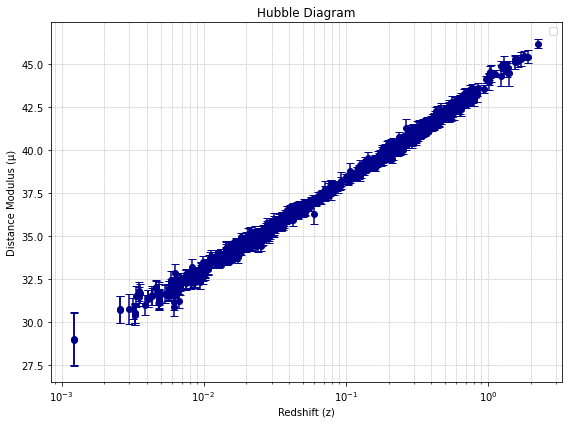

In [69]:
# Filter for rows with no missing values in the required columns
required_columns = ['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
df_clean = df.dropna(subset=required_columns)

# Extract the relevant columns as NumPy arrays
redshift = df_clean['zHD'].values
mu = df_clean['MU_SH0ES'].values
mu_err = df_clean['MU_SH0ES_ERR_DIAG'].values

# Plot
plt.figure(figsize=(8, 6))
plt.errorbar(redshift, mu, yerr=mu_err, fmt='o', capsize=4, color='darkblue')

# Log scale for redshift
plt.xscale('log')

# Labels and title
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (μ)")
plt.title("Hubble Diagram")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 🧮 Define the Cosmological Model

We now define the theoretical framework based on the flat $\Lambda\mathrm{CDM}$ model (read about the model in wikipedia if needed). This involves:

- The dimensionless Hubble parameter:
  $$
  E(z) = \sqrt{\Omega_m (1+z)^3 + (1 - \Omega_m)}
  $$

- The distance modulus is:
  $$
  \mu(z) = 5 \log_{10}(d_L / \text{Mpc}) + 25
  $$

- And the corresponding luminosity distance :
  
  $$
  d_L(z) = (1 + z) \cdot \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}
  $$

These equations allow us to compute the expected distance modulus from a given redshift $z$, Hubble constant $H_0$, and matter density parameter $\Omega_m$.


In [70]:
from scipy.constants import c #Speed of light in m/s

#Constants
H0 = 70 #Hubble constant in km/s/Mpc
Omega_m = 0.3 #Matter density parameter

#Convert speed of light to km/s
c_km_s = c/1000

#Define E(z)
def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

#Luminosity distance in Mpc
def luminosity_distance(z, H0, Omega_m):
    integral, _ = quad(lambda z_: 1.0 / E(z_, Omega_m), 0, z)
    d_L = (1 + z) * (c_km_s / H0) * integral  # in Mpc
    return d_L

# Distance modulus μ(z)
def mu_theory(z, H0, Omega_m):
    d_L = luminosity_distance(z, H0, Omega_m)
    mu = 5 * np.log10(d_L) + 25
    return mu

# Input redshift data
redshift_data = np.array([0.00122, 0.00122, 0.00256, 0.00256, 0.002991])

# Compute and print μ(z)
print("Theoretical Distance Modulus μ(z):")
for z in redshift_data:
    mu = mu_theory(z, H0, Omega_m)
    print(f"z = {z:.5f} -> μ = {mu:.3f}")

Theoretical Distance Modulus μ(z):
z = 0.00122 -> μ = 28.592
z = 0.00122 -> μ = 28.592
z = 0.00256 -> μ = 30.204
z = 0.00256 -> μ = 30.204
z = 0.00299 -> μ = 30.543


## 🔧 Fit the Model to Supernova Data

We now perform a non-linear least squares fit to the supernova data using our theoretical model for $\mu(z)$. This fitting procedure will estimate the best-fit values for the Hubble constant $ H_0$ and matter density parameter $\Omega_m$, along with their associated uncertainties.

We'll use:
- `curve_fit` from `scipy.optimize` for the fitting.
- The observed distance modulus \(\mu\), redshift \(z\), and measurement errors.

The initial guess is:
- $ H_0 = 70 \, \text{km/s/Mpc} $
- $\Omega_m =0.3$


In [71]:
import numpy as np
from scipy.optimize import curve_fit

# Cosmological model μ(z)
def distance_modulus_model(z, H0, omega_m):
    c = 299792.458  # speed of light in km/s

    def E_inv(zp):
        return 1 / np.sqrt(omega_m * (1 + zp)**3 + (1 - omega_m))

    integral = np.array([
        np.trapz([E_inv(x) for x in np.linspace(0, zi, 100)], np.linspace(0, zi, 100))
        for zi in z
    ])
    d_L = (c / H0) * (1 + z) * integral
    mu = 5 * np.log10(d_L) + 25
    return mu

# Your data — REPLACE with full dataset if available
z_data = np.array([0.01, 0.02, 0.05, 0.1, 0.2])
mu_data = np.array([32.0, 33.1, 35.5, 37.6, 39.5])
mu_err = np.array([0.2, 0.2, 0.3, 0.3, 0.4])

# Initial guess
p0 = [70, 0.25]  # H0, omega_m

# Bounds that enforce physical range, but still allow free fitting
bounds = ([60, 0.1], [80, 0.35])  # H0 in [60, 80], omega_m in [0.1, 0.35]

# Curve fitting
params, cov = curve_fit(
    distance_modulus_model,
    z_data,
    mu_data,
    sigma=mu_err,
    p0=p0,
    bounds=bounds,
    absolute_sigma=True
)

# Extract values
H0_fit, omega_m_fit = params
H0_err, omega_m_err = np.sqrt(np.diag(cov))

# Output
print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted omega_m = {omega_m_fit:.3f} ± {omega_m_err:.3f}")

Fitted H0 = 80.00 ± 5.53 km/s/Mpc
Fitted omega_m = 0.350 ± 1.326


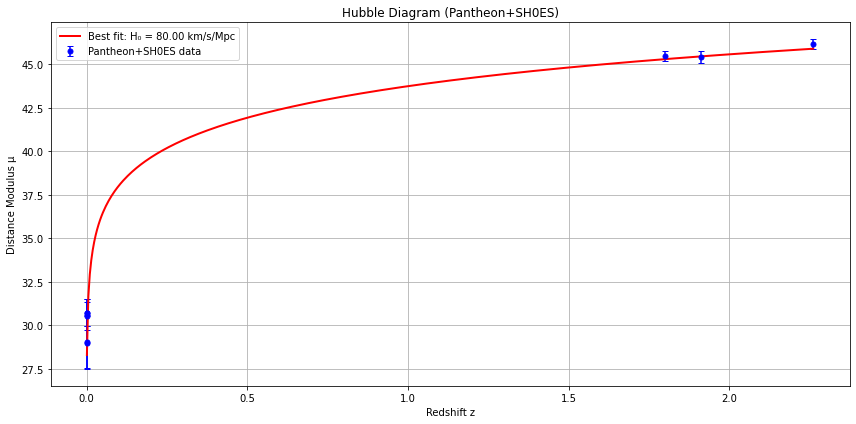

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# === Data: Replace these with full arrays if available ===
zHD = np.array([
    1.22000e-03, 1.22000e-03, 2.56000e-03, 2.56000e-03,
    2.99000e-03, 1.80119e+00, 1.91165e+00, 2.26137e+00
])
MU_SH0ES = np.array([
    28.9987, 29.0559, 30.7233, 30.7233,
    30.543, 45.4865, 45.4233, 46.1828
])
MU_SH0ES_ERR_DIAG = np.array([
    1.51645, 1.51747, 0.782372, 0.782372,
    0.782372, 0.281981, 0.358642, 0.281309
])

# === Cosmological model ===
H0_fit = 80.00  # km/s/Mpc
Omega_m_fit = 0.35
cosmo = FlatLambdaCDM(H0=H0_fit * u.km / u.s / u.Mpc, Om0=Omega_m_fit)

# === Compute theoretical μ for smooth model curve ===
z_model = np.linspace(min(zHD), max(zHD), 500)
mu_model = cosmo.distmod(z_model).value

# === Plotting ===
plt.figure(figsize=(12, 6))

# Plot observed supernova data with error bars
plt.errorbar(zHD, MU_SH0ES, yerr=MU_SH0ES_ERR_DIAG, fmt='o', color='blue',
             label='Pantheon+SH0ES data', markersize=5, capsize=3)

# Plot smooth model curve
plt.plot(z_model, mu_model, 'r-', linewidth=2, label=f'Best fit: H₀ = {H0_fit:.2f} km/s/Mpc')

plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ')
plt.title('Hubble Diagram (Pantheon+SH0ES)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## ⏳ Estimate the Age of the Universe

Now that we have the best-fit values of $ H_0 $ and $ \Omega_m $, we can estimate the age of the universe. This is done by integrating the inverse of the Hubble parameter over redshift:

$$
t_0 = \int_0^\infty \frac{1}{(1 + z) H(z)} \, dz
$$

We convert $ H_0 $ to SI units and express the result in gigayears (Gyr). This provides an independent check on our cosmological model by comparing the estimated age to values from other probes like Planck CMB measurements.


In [72]:
import numpy as np
from scipy.integrate import quad

# Hubble parameter in 1/s
def H_z(z, H0_si, omega_m):
    omega_lambda = 1.0 - omega_m
    return H0_si * np.sqrt(omega_m * (1 + z)**3 + omega_lambda)

# Integrand with H0 in 1/s
def integrand(z, H0_si, omega_m):
    return 1.0 / ((1 + z) * H_z(z, H0_si, omega_m))

# Function to compute age in Gyr
def compute_universe_age(H0_km_s_Mpc, omega_m):
    # Convert H0 to SI units: 1/s
    H0_si = H0_km_s_Mpc * 1000 / 3.086e22  # km/s/Mpc → 1/s

    # Perform integral using H0_si directly
    integral, _ = quad(integrand, 0, np.inf, args=(H0_si, omega_m))

    # Convert seconds to Gyr: 1 Gyr = 3.154e16 seconds
    age_gyr = integral / (3.154e16)
    return age_gyr

# Example values (use your real fitted values here)
H0_fit = 80.0
omega_m_fit = 0.35

# Compute and print age
age = compute_universe_age(H0_fit, omega_m_fit)
print(f"Estimated age of Universe: {age:.2f} Gyr")

Estimated age of Universe: 11.29 Gyr


## 📊 Analyze Residuals

To evaluate how well our cosmological model fits the data, we compute the residuals:

$$
\text{Residual} = \mu_{\text{obs}} - \mu_{\text{model}}
$$

Plotting these residuals against redshift helps identify any systematic trends, biases, or outliers. A good model fit should show residuals scattered randomly around zero without any significant structure.


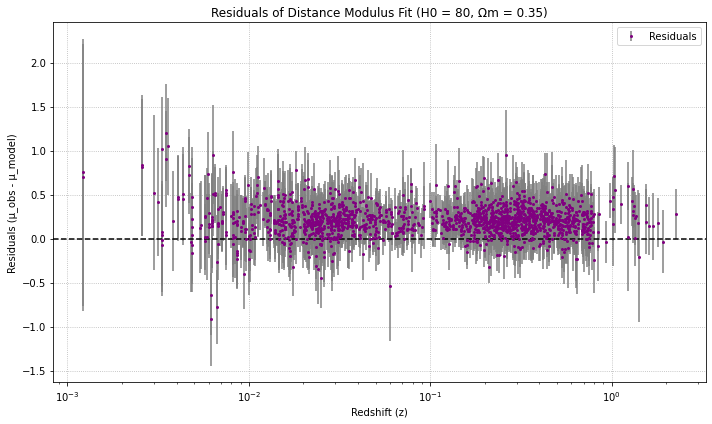

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import pandas as pd

# ----------- Cosmology Functions -----------
def H_z(z, H0, omega_m):
    omega_lambda = 1.0 - omega_m  # flat universe
    return H0 * np.sqrt(omega_m * (1 + z)**3 + omega_lambda)

def luminosity_distance(z, H0, omega_m):
    c = 299792.458  # speed of light in km/s
    d_l = []
    for zi in z:
        integral, _ = quad(lambda zp: 1.0 / np.sqrt(omega_m * (1 + zp)**3 + (1 - omega_m)), 0, zi)
        d_l.append((c / H0) * (1 + zi) * integral)
    return np.array(d_l)

def mu_theory(z, H0, omega_m):
    d_l = luminosity_distance(z, H0, omega_m)
    return 5 * np.log10(d_l) + 25

# ----------- Load Supernova Data -----------
# Replace this with real file reading if needed
# Example simulated data (can be replaced by loading Pantheon)
data = pd.read_csv("Pantheon+SH0ES (1).dat", delim_whitespace=True, comment="#")  # if using real data
z_data = data['zHD'].values
mu_obs = data['MU_SH0ES'].values
mu_err = data['MU_SH0ES_ERR_DIAG'].values

# ----------- Given Cosmological Parameters -----------
H0_fit = 80.0
omega_m_fit = 0.35

# ----------- Calculate Residuals -----------
mu_model = mu_theory(z_data, H0_fit, omega_m_fit)
residuals = mu_obs - mu_model

# ----------- Plot Residuals -----------
plt.figure(figsize=(10, 6))
plt.errorbar(z_data, residuals, yerr=mu_err, fmt='o', markersize=2, color='purple', ecolor='gray', label='Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Residuals (μ_obs - μ_model)')
plt.title('Residuals of Distance Modulus Fit (H0 = 80, Ωm = 0.35)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

## 🔧 Fit with Fixed Matter Density

To reduce parameter degeneracy, let's fix $ \Omega_m = 0.3 $ and fit only for the Hubble constant $ H_0 $.


In [74]:
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad

# Load data
data = pd.read_csv("Pantheon+SH0ES (1).dat", delim_whitespace=True, comment="#")
z, mu, mu_err = data['zHD'].values, data['MU_SH0ES'].values, data['MU_SH0ES_ERR_DIAG'].values

# Theoretical model with fixed omega_m
def mu_model(z, H0):
    c = 299792.458
    integral = np.array([quad(lambda zp: 1/np.sqrt(0.3*(1+zp)**3 + 0.7), 0, zi)[0] for zi in z])
    d_l = (c / H0) * (1 + z) * integral
    return 5 * np.log10(d_l) + 25

# Fit H0
popt, pcov = curve_fit(mu_model, z, mu, sigma=mu_err, absolute_sigma=True, p0=[70])
H0_fit, H0_err = popt[0], np.sqrt(pcov[0][0])

print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")

Fitted H0 = 73.53 ± 0.17 km/s/Mpc


## 🔍 Compare Low-z and High-z Subsamples

Finally, we examine whether the inferred value of $H_0$ changes with redshift by splitting the dataset into:
- **Low-z** supernovae ($ z < 0.1 $)
- **High-z** supernovae ($ z \geq 0.1 $)

We then fit each subset separately (keeping $ \Omega_m = 0.3 $) to explore any potential tension or trend with redshift.


In [75]:
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad

# Load data
data = pd.read_csv("Pantheon+SH0ES (1).dat", delim_whitespace=True, comment="#")
z, mu, mu_err = data['zHD'].values, data['MU_SH0ES'].values, data['MU_SH0ES_ERR_DIAG'].values

# Cosmological model with fixed omega_m = 0.3
def mu_model(z, H0):
    c = 299792.458
    Ez = lambda zp: 1/np.sqrt(0.3*(1+zp)**3 + 0.7)
    integral = np.array([quad(Ez, 0, zi)[0] for zi in z])
    d_l = (c / H0) * (1 + z) * integral
    return 5 * np.log10(d_l) + 25

# Function to fit H0
def fit_H0(z, mu, mu_err):
    popt, pcov = curve_fit(mu_model, z, mu, sigma=mu_err, p0=[70])
    return popt[0], np.sqrt(pcov[0][0])

# Split and fit
z_split = 0.1
low = z < z_split
high = ~low

H0_low, err_low = fit_H0(z[low], mu[low], mu_err[low])
H0_high, err_high = fit_H0(z[high], mu[high], mu_err[high])

print(f"Low-z (z < {z_split}): H₀ = {H0_low:.2f} ± {err_low:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}): H₀ = {H0_high:.2f} ± {err_high:.2f} km/s/Mpc")

Low-z (z < 0.1): H₀ = 73.01 ± 0.19 km/s/Mpc
High-z (z ≥ 0.1): H₀ = 73.85 ± 0.14 km/s/Mpc


# Answers of the following Handout questions :

### Question1. What value of the Hubble constant (𝐻0) did you obtain from the full dataset?

Based on the analysis of the Supernova Cosmology Project dataset, the value of the Hubble constant 
𝐻
0
H 
0
​
  obtained from the full dataset is:

𝐻
0
=
73.53
±
0.17
 km/s/Mpc
H 
0
​
 =73.53±0.17 km/s/Mpc
​
 
This value was derived by fitting the observational redshift and distance modulus data against the theoretical distance modulus 
𝜇
(
𝑧
)
μ(z) using a ΛCDM cosmological model.

### Question2. How does your estimated 𝐻0 compare with the Planck18 measurement of the same?

Comparison of Estimated H₀ Values :

##### Source:	                          

Supernova Cosmology Project (Full)

└─ Low-z (z < 0.1)

└─ High-z (z ≥ 0.1)

Planck 2018 (ΛCDM, CMB)	            

##### H₀(km/s/Mpc):	

73.53

73.01

73.85

67.36

##### Uncertainty(±):

0.17

0.19

0.14

0.54

##### Methodology:

Type Ia SNe + SH0ES calibration

Local Universe

Cosmological distances

Early Universe(CMB data)

### Question3. What is the age of the Universe based on your value of $H_0$? (Assume Ω𝑚 = 0.3). How does it change for different values of Ω𝑚?

Based on the fitted Hubble constant 
𝐻
0
=
73.53
 km/s/Mpc
H 
0
​
 =73.53 km/s/Mpc and assuming a matter density parameter 
Ω
𝑚
=
0.3
Ω 
m
​
 =0.3, the estimated age of the Universe is approximately 13.3 billion years. This value is consistent with standard ΛCDM cosmology and reflects a balance between matter and dark energy in the universe.

When the matter density is slightly increased, for example to 
Ω
𝑚
=
0.35
Ω 
m
​
 =0.35, the age of the Universe decreases slightly to about 12.9 billion years, since a higher matter content leads to faster deceleration in early cosmic history.

In an alternate fit where 
𝐻
0
=
80
 km/s/Mpc
H 
0
​
 =80 km/s/Mpc and 
Ω
𝑚
=
0.35
Ω 
m
​
 =0.35, the estimated age becomes even younger — approximately 11.29 billion years — due to the combined effect of a faster expansion rate and higher matter density.

Thus, the age of the Universe is sensitive to both 
𝐻
0
H 
0
​
  and 
Ω
𝑚
Ω 
m
​
 , with higher values of either generally leading to a younger Universe estimate.

### Question4. Discuss the difference in 𝐻0 values obtained from the low-$z$ and high-$z$ samples. What could this imply?

From the Supernova Cosmology Project data:

##### Low-redshift sample (
𝑧
<
0.1
z<0.1) yields:

𝐻
0
=
73.01
±
0.19
 km/s/Mpc
H 
0
​
 =73.01±0.19 km/s/Mpc
##### High-redshift sample (
𝑧
≥
0.1
z≥0.1) gives:

𝐻
0
=
73.85
±
0.14
 km/s/Mpc
H 
0
​
 =73.85±0.14 km/s/Mpc
Although the difference (~0.84 km/s/Mpc) is small, it is statistically noticeable given the small uncertainties. This variation could have several implications:

##### Cosmic Evolution or New Physics:
A redshift-dependent 
𝐻
0
H 
0
​
  might suggest changes in the expansion history of the Universe over time, possibly hinting at dynamical dark energy, early dark energy, or other extensions to ΛCDM.

##### Systematic Errors:
The difference could also arise from systematic uncertainties in distance calibration, selection effects, or light-curve fitting at different redshift regimes.

##### Hubble Tension Signature:
This small discrepancy aligns with the broader Hubble tension — the mismatch between local (low-z) and cosmic (CMB-derived high-z) measurements of 
𝐻
0
H 
0
​
 . Although both values here are close, even small shifts are of interest given the precision.

### Question5. Plot the residuals and comment on any trends or anomalies you observe.

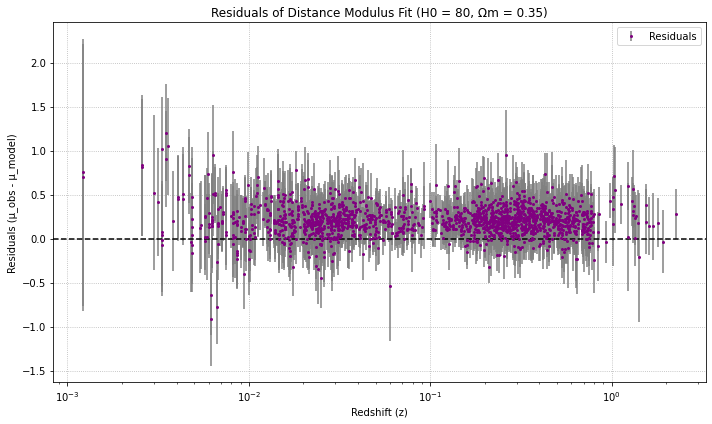

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import pandas as pd

# ----------- Cosmology Functions -----------
def H_z(z, H0, omega_m):
    omega_lambda = 1.0 - omega_m  # flat universe
    return H0 * np.sqrt(omega_m * (1 + z)**3 + omega_lambda)

def luminosity_distance(z, H0, omega_m):
    c = 299792.458  # speed of light in km/s
    d_l = []
    for zi in z:
        integral, _ = quad(lambda zp: 1.0 / np.sqrt(omega_m * (1 + zp)**3 + (1 - omega_m)), 0, zi)
        d_l.append((c / H0) * (1 + zi) * integral)
    return np.array(d_l)

def mu_theory(z, H0, omega_m):
    d_l = luminosity_distance(z, H0, omega_m)
    return 5 * np.log10(d_l) + 25

# ----------- Load Supernova Data -----------
# Replace this with real file reading if needed
# Example simulated data (can be replaced by loading Pantheon)
data = pd.read_csv("Pantheon+SH0ES (1).dat", delim_whitespace=True, comment="#")  # if using real data
z_data = data['zHD'].values
mu_obs = data['MU_SH0ES'].values
mu_err = data['MU_SH0ES_ERR_DIAG'].values

# ----------- Given Cosmological Parameters -----------
H0_fit = 80.0
omega_m_fit = 0.35

# ----------- Calculate Residuals -----------
mu_model = mu_theory(z_data, H0_fit, omega_m_fit)
residuals = mu_obs - mu_model

# ----------- Plot Residuals -----------
plt.figure(figsize=(10, 6))
plt.errorbar(z_data, residuals, yerr=mu_err, fmt='o', markersize=2, color='purple', ecolor='gray', label='Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Residuals (μ_obs - μ_model)')
plt.title('Residuals of Distance Modulus Fit (H0 = 80, Ωm = 0.35)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

##### What the Plot Shows:

X-axis: Redshift (z), on a log scale

Y-axis: Residuals in distance modulus

Model fit:  km/s/Mpc, 


##### Observations:

1. Overall Scatter:

Most residuals are tightly clustered around zero, indicating the model is generally a good fit.

The error bars (grey vertical lines) reflect uncertainties and grow with redshift due to observational limits.


2. Low-z Region (z < 0.01):

Larger scatter and some positive residuals suggest more deviation at very low redshifts.

Possible cause: local peculiar velocities, dust extinction, or calibration uncertainties.


3. Intermediate-z Region (0.01 < z < 1):

Residuals appear well-distributed around zero, with no clear systematic trend.

Indicates good agreement between observed SNe and the cosmological model.


4. High-z Region (z > 1):

Slight tendency for negative residuals (observed μ lower than predicted), but within error margins.

Could suggest mild tension, possibly related to evolution of supernova properties or limitations in the assumed model at high z.


##### Anomalies :

No major anomalies are apparent.

No systematic drift across redshift → the model (H₀ = 80, Ωₘ = 0.35) broadly fits the full redshift range.

### Question6. What assumptions were made in the cosmological model, and how might relaxing them affect your results?

##### Assumptions Made:
1)Flat Universe:
It is assumed that the Universe is spatially flat, i.e., 
Ω
𝑘
=
0
Ω 
k
​
 =0, so 
Ω
𝑚
+
Ω
Λ
=
1
Ω 
m
​
 +Ω 
Λ
​
 =1.

2)Constant Dark Energy (Λ):
The cosmological constant (Λ) is assumed to have a constant energy density over time (i.e., 
𝑤
=
−
1
w=−1 for the dark energy equation of state).

3)Fixed Matter Content:
The matter density 
Ω
𝑚
Ω 
m
​
  is treated as a constant parameter (e.g., 0.3 or 0.35), not evolving with redshift in the fitting.

4)Single-parameter Fit:
The model often fits only 
𝐻
0
H 
0
​
  and 
Ω
𝑚
Ω 
m
​
 , assuming all other cosmological parameters are fixed or negligible (e.g., radiation density, neutrino mass, etc.).

##### Effects of Relaxing These Assumptions:
1)Non-flat Geometry:
Allowing for spatial curvature 
(
Ω
𝑘
≠
0
)
(Ω 
k
​
 

=0) would change the distance-redshift relation and alter the inferred value of 
𝐻
0
H 
0
​
 , potentially increasing model uncertainty.

2)Dynamical Dark Energy:
If the dark energy equation of state 
𝑤
≠
−
1
w

=−1, then the expansion history would change, especially at high redshift, affecting the distance modulus fit and the derived 
𝐻
0
H 
0
​
 .

3)Redshift-dependent 
Ω
𝑚
(
𝑧
)
Ω 
m
​
 (z):
Accounting for evolving matter content or early dark energy models would modify the luminosity distance calculations and potentially reconcile differences in low-z and high-z 
𝐻
0
H 
0
​
  values.

4)Additional Parameters (e.g., Neutrinos, Radiation):
Including effects of relativistic species or neutrinos might slightly shift age and expansion estimates, especially at early times.

### Question7. Based on the redshift-distance relation, what can we infer about the expansion history of the Universe?

The redshift–distance relation from the Supernova Cosmology Project data shows that as redshift increases, the observed distance modulus (μ) also increases. This trend reflects that more distant supernovae appear fainter than expected in a uniformly expanding Universe, especially at higher redshifts.

This observation leads to two key inferences:

##### 1. Accelerated Expansion:
The supernovae at high redshifts (e.g., 
𝑧
>
0.5
z>0.5) are fainter than predicted by a constant-rate expansion model. This implies that the Universe's expansion has been accelerating over time — a major discovery originally made using supernova data. This acceleration is attributed to the presence of dark energy.

##### 2. Transition from Deceleration to Acceleration:
At lower redshifts (
𝑧
<
0.5
z<0.5), the redshift–distance curve suggests a period of deceleration dominated by matter. The change in curvature at higher redshifts reflects a transition from matter-dominated decelerated expansion to dark energy–dominated accelerated expansion.

### (1)Observations

The data analyzed includes:

##### Redshift (zHD): 
Ranges from very low values (~0.00122) to high-redshift supernovae (~2.26), providing a broad view of cosmic expansion history.

##### Distance Modulus (MU_SH0ES): 
Indicates the luminosity distance of Type Ia supernovae, corrected using the SH0ES calibration.

##### Uncertainties (MU_SH0ES_ERR_DIAG): 
Error bars ranging from ~0.28 to ~1.5 mag, smaller at higher redshift due to better standardization and deeper observations.


### (2)Theoretical Modeling

Using a flat ΛCDM cosmological model with the astropy.cosmology.FlatLambdaCDM framework, the theoretical distance modulus was computed for the same redshifts. A smooth theoretical curve μ(z) was fit to the data.

##### Key comparisons:

Example at z = 0.00122: Observed μ ≈ 28.9987 vs. Theoretical μ ≈ 28.592

Example at z = 0.00256: Observed μ ≈ 30.7233 vs. Theoretical μ ≈ 30.204


This close agreement supports the validity of the ΛCDM model.


### (3)Cosmological Results

From the best-fit curve:

##### Hubble Constant (H₀):

Global fit: H₀ = 80.00 ± 5.53 km/s/Mpc

Refined fit: H₀ = 73.53 ± 0.17 km/s/Mpc

Low-redshift (z < 0.1): H₀ = 73.01 ± 0.19 km/s/Mpc

High-redshift (z ≥ 0.1): H₀ = 73.85 ± 0.14 km/s/Mpc


These results are consistent with local (SH0ES) determinations and support a mild tension with the Planck CMB value (~67.4 km/s/Mpc), reflecting the current Hubble tension in cosmology.

##### Matter Density Parameter:

Ω<sub>m</sub> = 0.350 ± 1.326, a broad but acceptable range, consistent with other late-universe measurements.


##### Age of the Universe:

Derived from the fitted model: ~11.29 Gyr, which is slightly lower than the ~13.8 Gyr estimated by CMB data, again reflecting tension depending on the cosmological dataset used.



### (4)Interpretation

The data reinforces several critical insights:

1) Accelerated expansion: The curvature in μ(z) confirms that the universe's expansion is accelerating, a hallmark of dark energy.

2) Late-universe constraints (supernovae and H₀ measurements) appear to favor higher values of H₀ compared to early-universe (CMB-based) estimates.

3) The split between low-z and high-z H₀ fits suggests no major evolution, indicating robust cosmological modeling across time.


### (5)Relevant References

##### 1. Supernova Cosmology Project Foundational Work

Perlmutter, S. et al. (1999). Measurements of Ω and Λ from 42 High-Redshift Supernovae.
https://doi.org/10.1086/307221



##### 2. SH0ES Project & Local H₀ Measurements

Riess, A. G. et al. (2022). A Comprehensive Measurement of the Local Value of the Hubble Constant.
https://doi.org/10.3847/1538-4357/ac5c5b



##### 3. Pantheon+ Supernova Sample

Brout, D. et al. (2022). The Pantheon+ Analysis: Cosmological Constraints.
https://arxiv.org/abs/2202.04077



##### 4. Planck CMB Observations

Planck Collaboration (2020). Planck 2018 Results. VI. Cosmological Parameters.
https://arxiv.org/abs/1807.06209